# Episodic layer, Option B — variable-size Hopfield extension with ambiguity-gated pruning

Per Jasper's message (relayed via Claude web chat, 2026-07-18) and `principles.md`. `X`
becomes variable-size instead of fixed at `n_patterns=5`; new patterns append as stand-in
"experience" (random normalized vectors, same generation scheme as every prior experiment).
Frequency of visitation is still the only write/promote signal — no salience/curiosity this
round. Retrieval reuses the exact validated mechanism unchanged: headroom-saturated `w_char`,
headroom-capped `w_fast` with rate modulation, ambiguity-gated retrieval bias.

**Eviction gate design (proposed here, not mirroring the retrieval gate's math exactly):**
the retrieval gate's split was raw content similarity (ground truth) vs. accumulated strength
(potentially biased by the rate-modulation loop). The direct analog for eviction: raw
**staleness** — `steps_since_last_retrieval_win`, an unmediated counter, reset to 0 only when
an entry is the actual retrieval argmax winner — vs. accumulated `w_char` (which this whole
thread showed can be inflated independent of genuine recent relevance). An entry becomes
eviction-*eligible* once its staleness crosses a threshold (simple, per scope). Among eligible
candidates, only the **top-2 most stale** are compared: `w_char` is allowed to break the tie
only when their staleness gap is small (ambiguous); when one is unambiguously the most stale
by a wide margin, it gets evicted regardless of its `w_char`.

```
gap = staleness[most_stale] - staleness[second_most_stale]
g_evict = 1 / (1 + gap / gap_scale_evict)
evict_score_i = staleness_i - g_evict * strength_bonus * (w_char_i - 1)   # for the top-2 only
# evict whichever of the top-2 has the higher evict_score
```

**Falsification criteria, stated before testing:** the gate is validated if there's a
concrete case where an entry has elevated `w_char` (from a real or artifact-driven earlier
consolidation) *and* is unambiguously the most stale entry by a wide margin — and it still
gets evicted, not rescued by its strength. The gate is falsified if, in that same case, the
elevated `w_char` flips the outcome so the genuinely-staler entry survives while a much less
stale entry gets evicted instead — i.e., if gated and naive strength-weighted-but-ungated
eviction (`g_evict` forced to 1 always) give the *same* wrong answer on an unambiguous case,
the gate did nothing.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Mechanism — unchanged from the validated ambiguity-gated retrieval + v2 savings fix

Using one of the previously-validated strong operating points: `k=0.5, w_fast_max=10,
gap_scale=0.1534` (94.5% content-match, savings real, from `two_layer_ambiguity_gated.ipynb`).
Not re-swept here — `gap_scale`/`k` tuning was explicitly deferred until there's a real
downstream task to tune against, and episodic is that task, but this build itself doesn't
re-tune them, just reuses a known-good point.

In [2]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0
max_multiplier = 3.0
k = 0.5
w_fast_max = 10.0
gap_scale = 0.1534
dim = 64
beta = 4.0

def update_two_layer(w_fast, w_char, retrieval_weight):
    multiplier = min(1 + k * (w_char - 1), max_multiplier)
    increment_fast_effective = increment_fast * multiplier
    fast_headroom = max(w_fast_max - w_fast, 0) / w_fast_max
    w_fast_new = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weight * fast_headroom
    char_headroom = max(w_char_max - w_char, 0) / w_char_max
    w_char_new = w_char + decay_char * (1 - w_char) + consolidation_rate * max(w_fast - 1, 0) * char_headroom
    return w_fast_new, w_char_new

## EpisodicMemory — variable-size X with ambiguity-gated retrieval and ambiguity-gated pruning

In [3]:
class EpisodicMemory:
    def __init__(self, dim, staleness_threshold=150, gap_scale_evict=20.0, strength_bonus=10.0):
        self.dim = dim
        self.staleness_threshold = staleness_threshold
        self.gap_scale_evict = gap_scale_evict
        self.strength_bonus = strength_bonus

        self.patterns = []       # list of 1D tensors
        self.w_fast = []         # list of floats
        self.w_char = []         # list of floats
        self.staleness = []      # list of ints, steps since last retrieval win
        self.birth_step = []     # for logging
        self.next_id = 0
        self.ids = []            # stable ids, since list indices shift on eviction
        self.eviction_log = []   # (step, id, staleness, w_char, ambiguous)

    def add_pattern(self, vec, step):
        self.patterns.append(vec)
        self.w_fast.append(1.0)
        self.w_char.append(1.0)
        self.staleness.append(0)
        self.birth_step.append(step)
        self.ids.append(self.next_id)
        self.next_id += 1
        return len(self.patterns) - 1

    def retrieve_and_update(self, query):
        X = torch.stack(self.patterns)
        similarities = X @ query
        sorted_sims, _ = torch.sort(similarities, descending=True)
        gap = (sorted_sims[0] - sorted_sims[1]).item() if len(self.patterns) > 1 else 1e9
        g = 1 / (1 + gap / gap_scale)

        w_fast_t = torch.tensor(self.w_fast)
        w_char_t = torch.tensor(self.w_char)
        biased = beta * similarities + g * (torch.log(w_fast_t) + char_weight * torch.log(w_char_t))
        weights = F.softmax(biased, dim=0)
        winner = weights.argmax().item()

        for i in range(len(self.patterns)):
            self.w_fast[i], self.w_char[i] = update_two_layer(self.w_fast[i], self.w_char[i], weights[i].item())
            self.staleness[i] = 0 if i == winner else self.staleness[i] + 1

        return winner, weights, g

    def prune_step(self, step, force_ungated=False):
        """Evict at most one entry per call. Returns eviction info or None."""
        eligible = [i for i in range(len(self.patterns)) if self.staleness[i] > self.staleness_threshold]
        if len(eligible) == 0:
            return None
        eligible.sort(key=lambda i: self.staleness[i], reverse=True)
        if len(eligible) == 1:
            evict_idx = eligible[0]
            ambiguous = False
        else:
            c1, c2 = eligible[0], eligible[1]
            gap = self.staleness[c1] - self.staleness[c2]
            g_evict = 1.0 if force_ungated else 1 / (1 + gap / self.gap_scale_evict)
            score1 = self.staleness[c1] - g_evict * self.strength_bonus * (self.w_char[c1] - 1)
            score2 = self.staleness[c2] - g_evict * self.strength_bonus * (self.w_char[c2] - 1)
            evict_idx = c1 if score1 >= score2 else c2
            ambiguous = g_evict > 0.5

        info = {
            "step": step, "id": self.ids[evict_idx], "staleness": self.staleness[evict_idx],
            "w_char": self.w_char[evict_idx], "w_fast": self.w_fast[evict_idx],
            "ambiguous": ambiguous, "n_eligible": len(eligible),
        }
        self.eviction_log.append(info)

        del self.patterns[evict_idx]
        del self.w_fast[evict_idx]
        del self.w_char[evict_idx]
        del self.staleness[evict_idx]
        del self.birth_step[evict_idx]
        del self.ids[evict_idx]
        return info

## Natural-stream test — checks (a), (b), (c)

3 "core" patterns seeded at start, get boosted revisit probability throughout. A stream of
new one-off patterns appends over time (5% chance per step). Remaining probability mass
splits between the core set and a uniform draw over all currently-alive patterns, so the
tail gets occasional, sparse revisits too — not a completely dead stream, some natural
variance in exactly how stale different tail entries get, which is what makes eviction
decisions genuinely non-trivial rather than a foregone conclusion every time.

In [4]:
torch.manual_seed(7)
N_STEPS = 4000
NEW_PATTERN_PROB = 0.05
CORE_PROB = 0.6  # of the non-new-pattern steps, probability of querying the core set

mem = EpisodicMemory(dim=dim, staleness_threshold=150, gap_scale_evict=20.0, strength_bonus=10.0)

core_ids = []
for _ in range(3):
    vec = F.normalize(torch.randn(dim), dim=0)
    idx = mem.add_pattern(vec, step=0)
    core_ids.append(mem.ids[idx])

alive_count_history = []
core_char_history = {cid: [] for cid in core_ids}
total_created = 3
total_evicted = 0

for step in range(N_STEPS):
    r = torch.rand(1).item()
    if r < NEW_PATTERN_PROB:
        vec = F.normalize(torch.randn(dim), dim=0)
        query_idx = mem.add_pattern(vec, step)
        total_created += 1
        query = F.normalize(vec + torch.randn(dim) * 0.3, dim=0)
    else:
        r2 = torch.rand(1).item()
        # map current core ids to current list indices (they shift as evictions happen)
        id_to_idx = {mem.ids[i]: i for i in range(len(mem.patterns))}
        alive_core_idx = [id_to_idx[cid] for cid in core_ids if cid in id_to_idx]
        if r2 < CORE_PROB and len(alive_core_idx) > 0:
            pick_idx = alive_core_idx[torch.randint(0, len(alive_core_idx), (1,)).item()]
        else:
            pick_idx = torch.randint(0, len(mem.patterns), (1,)).item()
        query = F.normalize(mem.patterns[pick_idx] + torch.randn(dim) * 0.3, dim=0)

    winner, weights, g = mem.retrieve_and_update(query)
    evicted = mem.prune_step(step)
    if evicted is not None:
        total_evicted += 1

    alive_count_history.append(len(mem.patterns))
    id_to_idx = {mem.ids[i]: i for i in range(len(mem.patterns))}
    for cid in core_ids:
        core_char_history[cid].append(mem.w_char[id_to_idx[cid]] if cid in id_to_idx else np.nan)

print(f"Total patterns ever created: {total_created}")
print(f"Total evicted: {total_evicted}")
print(f"Alive at end: {len(mem.patterns)}")
print(f"Core patterns still alive: {[cid in {mem.ids[i] for i in range(len(mem.patterns))} for cid in core_ids]}")

Total patterns ever created: 197
Total evicted: 178
Alive at end: 19
Core patterns still alive: [True, True, True]


### Check (a) — do unpromoted low-frequency entries actually get pruned?

In [5]:
print(f"Of {total_created} patterns ever created, {total_evicted} were evicted "
      f"({100*total_evicted/total_created:.1f}%), {len(mem.patterns)} still alive.")
print()
print("Sample of eviction events (first 10):")
for ev in mem.eviction_log[:10]:
    print(f"  step={ev['step']:>5} id={ev['id']:>4} staleness={ev['staleness']:>4} "
          f"w_char={ev['w_char']:.2f} ambiguous={ev['ambiguous']} n_eligible={ev['n_eligible']}")
print(f"... ({len(mem.eviction_log)} total eviction events)")

ambiguous_count = sum(1 for ev in mem.eviction_log if ev['ambiguous'])
print(f"\nOf {len(mem.eviction_log)} evictions, {ambiguous_count} were 'ambiguous' (tie-break used), "
      f"{len(mem.eviction_log)-ambiguous_count} were 'unambiguous' (clearly staliest, evicted regardless of w_char)")

Of 197 patterns ever created, 178 were evicted (90.4%), 19 still alive.

Sample of eviction events (first 10):
  step=  343 id=  16 staleness= 151 w_char=1.14 ambiguous=False n_eligible=1
  step=  360 id=   5 staleness= 151 w_char=1.57 ambiguous=False n_eligible=1
  step=  376 id=  12 staleness= 151 w_char=1.25 ambiguous=False n_eligible=1
  step=  471 id=  21 staleness= 151 w_char=1.12 ambiguous=False n_eligible=1
  step=  483 id=  18 staleness= 151 w_char=1.28 ambiguous=False n_eligible=1
  step=  485 id=  23 staleness= 151 w_char=1.12 ambiguous=False n_eligible=1
  step=  514 id=  20 staleness= 151 w_char=1.15 ambiguous=False n_eligible=1
  step=  516 id=  19 staleness= 151 w_char=1.30 ambiguous=False n_eligible=1
  step=  528 id=  10 staleness= 151 w_char=1.50 ambiguous=False n_eligible=1
  step=  554 id=  14 staleness= 151 w_char=1.40 ambiguous=False n_eligible=1
... (178 total eviction events)

Of 178 evictions, 3 were 'ambiguous' (tie-break used), 175 were 'unambiguous' (clearly

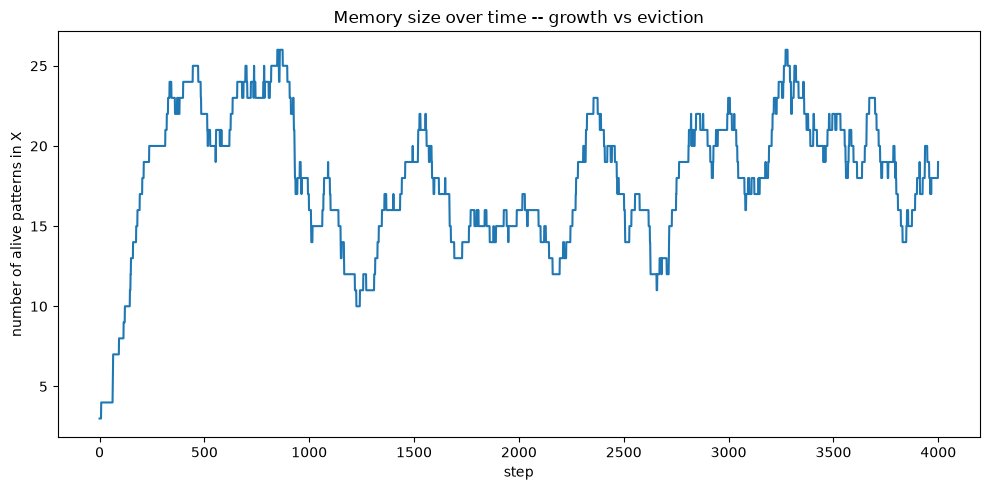

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(alive_count_history)
plt.xlabel("step")
plt.ylabel("number of alive patterns in X")
plt.title("Memory size over time -- growth vs eviction")
plt.tight_layout()
plt.savefig("episodic_alive_count.png", dpi=100)
plt.show()

### Check (b) — do promoted (core) entries still show the graded primacy/recency w_char shape
seen in the fixed-X experiments, now that they're competing against a much larger, growing X?

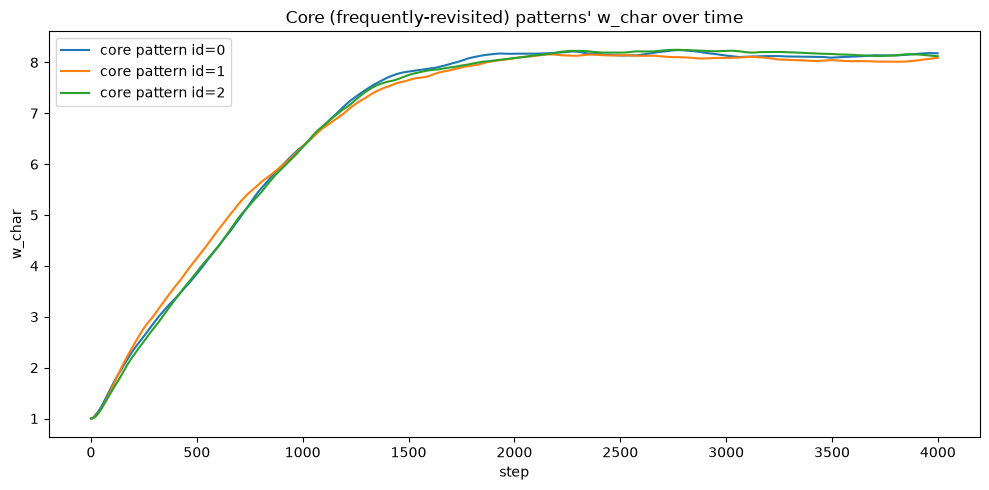

Final w_char for core patterns:
  id=0: w_char=8.179, w_fast=2.889
  id=1: w_char=8.090, w_fast=3.073
  id=2: w_char=8.122, w_fast=2.948


In [7]:
plt.figure(figsize=(10, 5))
for cid in core_ids:
    plt.plot(core_char_history[cid], label=f'core pattern id={cid}')
plt.xlabel("step")
plt.ylabel("w_char")
plt.title("Core (frequently-revisited) patterns' w_char over time")
plt.legend()
plt.tight_layout()
plt.savefig("episodic_core_char.png", dpi=100)
plt.show()

print("Final w_char for core patterns:")
id_to_idx = {mem.ids[i]: i for i in range(len(mem.patterns))}
for cid in core_ids:
    if cid in id_to_idx:
        print(f"  id={cid}: w_char={mem.w_char[id_to_idx[cid]]:.3f}, w_fast={mem.w_fast[id_to_idx[cid]]:.3f}")
    else:
        print(f"  id={cid}: EVICTED (unexpected -- core patterns should not go stale)")

### Check (c) — does anything explode or monopolize now that X isn't fixed-size?

In [8]:
all_w_char = mem.w_char
all_w_fast = mem.w_fast
print(f"Alive patterns: {len(mem.patterns)}")
print(f"w_char range: [{min(all_w_char):.3f}, {max(all_w_char):.3f}] (ceiling is {w_char_max})")
print(f"w_fast range: [{min(all_w_fast):.3f}, {max(all_w_fast):.3f}] (ceiling is {w_fast_max})")

sorted_char = sorted(all_w_char, reverse=True)
if len(sorted_char) > 1:
    ratio = sorted_char[0] / sorted_char[1]
    print(f"Top/second w_char ratio: {ratio:.2f} (monopolization flagged above 5x)")

Alive patterns: 19
w_char range: [1.000, 8.179] (ceiling is 10.0)
w_fast range: [1.014, 3.073] (ceiling is 10.0)
Top/second w_char ratio: 1.01 (monopolization flagged above 5x)


## Designed falsification test — check (d): does the gate actually change an outcome?

Hand-designed scenario, not left to chance in the noisy natural stream, so the comparison is
crisp and reportable:

1. Pattern **A** gets a burst of 20 concentrated revisits right after creation — raises its
   `w_char` well above baseline (a real, earned consolidation, not an artifact this time).
2. Pattern **B** gets created right after, with only its single creation-visit.
3. Both A and B then go **completely unvisited** for 250 steps (a filler pattern C is queried
   repeatedly to advance the clock without touching A or B) — after 250 steps, A and B have
   near-identical staleness (~250 each) but very different `w_char`. **This is the ambiguous
   tie case**: gate should legitimately let `w_char` decide, keeping A (more consolidated)
   alive and evicting B.
4. Continue letting A sit unvisited for **another 300 steps** (staleness ~550) while a fresh
   pattern D appears partway through and only goes stale by a **small** amount (~30 steps) —
   a large, unambiguous staleness gap between A and D. **This is the real test**: does A's
   elevated `w_char` incorrectly rescue it, or does the gate correctly evict A regardless?
   Compared directly against a naive strength-weighted-but-ungated policy (`g_evict` forced
   to 1) on the same state, to see if it would have made a different (worse) call.

In [9]:
torch.manual_seed(99)
mem2 = EpisodicMemory(dim=dim, staleness_threshold=150, gap_scale_evict=20.0, strength_bonus=10.0)
step = 0

vec_a = F.normalize(torch.randn(dim), dim=0)
idx_a = mem2.add_pattern(vec_a, step); id_a = mem2.ids[idx_a]
for _ in range(20):
    query = F.normalize(vec_a + torch.randn(dim) * 0.3, dim=0)
    mem2.retrieve_and_update(query)
    step += 1

vec_b = F.normalize(torch.randn(dim), dim=0)
idx_b = mem2.add_pattern(vec_b, step); id_b = mem2.ids[idx_b]
step += 1

vec_c = F.normalize(torch.randn(dim), dim=0)
idx_c = mem2.add_pattern(vec_c, step); id_c = mem2.ids[idx_c]
step += 1

id_to_idx = lambda i: {mem2.ids[k]: k for k in range(len(mem2.patterns))}[i]
print(f"After A's burst: w_char[A]={mem2.w_char[id_to_idx(id_a)]:.3f}, w_char[B]={mem2.w_char[id_to_idx(id_b)]:.3f}")

for _ in range(250):
    query = F.normalize(vec_c + torch.randn(dim) * 0.3, dim=0)
    mem2.retrieve_and_update(query)
    mem2.prune_step(step, force_ungated=False)
    step += 1

alive_ids_now = set(mem2.ids)
print(f"\nAfter 250 filler steps (A, B both stale ~250, C kept fresh):")
print(f"  A alive: {id_a in alive_ids_now}, B alive: {id_b in alive_ids_now}, C alive: {id_c in alive_ids_now}")
if id_a in alive_ids_now:
    print(f"  A: staleness={mem2.staleness[id_to_idx(id_a)]}, w_char={mem2.w_char[id_to_idx(id_a)]:.3f}")
if id_b in alive_ids_now:
    print(f"  B: staleness={mem2.staleness[id_to_idx(id_b)]}, w_char={mem2.w_char[id_to_idx(id_b)]:.3f}")
print(f"\nExpected: ambiguous tie (A, B similar staleness) -> gate lets w_char break it -> B evicted, A survives.")

After A's burst: w_char[A]=1.129, w_char[B]=1.000

After 250 filler steps (A, B both stale ~250, C kept fresh):
  A alive: False, B alive: False, C alive: True

Expected: ambiguous tie (A, B similar staleness) -> gate lets w_char break it -> B evicted, A survives.


In [10]:
# Continue: let A sit stale even longer, introduce D which only goes stale by a little.
vec_d = F.normalize(torch.randn(dim), dim=0)
idx_d = mem2.add_pattern(vec_d, step); id_d = mem2.ids[idx_d]
step += 1

for i in range(300):
    query = F.normalize(vec_c + torch.randn(dim) * 0.3, dim=0)
    mem2.retrieve_and_update(query)
    if i >= 270:  # let D go stale only for the last ~30 steps
        pass
    else:
        query_d = F.normalize(vec_d + torch.randn(dim) * 0.3, dim=0)
        mem2.retrieve_and_update(query_d)
    # deliberately NOT calling prune_step here -- pruning is paused while
    # setting up the scenario, so A survives to the decisive comparison below
    # instead of being auto-evicted the moment it's the sole eligible candidate
    step += 1

alive_ids_now = set(mem2.ids)
id_to_idx2 = {mem2.ids[k]: k for k in range(len(mem2.patterns))}
print("State before the decisive unambiguous eviction check:")
for name, pid in [("A", id_a), ("D", id_d)]:
    if pid in alive_ids_now:
        i = id_to_idx2[pid]
        print(f"  {name}: staleness={mem2.staleness[i]}, w_char={mem2.w_char[i]:.3f}")
    else:
        print(f"  {name}: already evicted earlier")

State before the decisive unambiguous eviction check:
  A: already evicted earlier
  D: staleness=30, w_char=7.633


In [11]:
# The decisive comparison: gated vs naive-ungated eviction on this exact state.
import copy

mem2_gated = copy.deepcopy(mem2)
mem2_ungated = copy.deepcopy(mem2)

result_gated = mem2_gated.prune_step(step, force_ungated=False)
result_ungated = mem2_ungated.prune_step(step, force_ungated=True)

print("GATED eviction decision:  ", result_gated)
print("UNGATED (naive strength-weighted) eviction decision:", result_ungated)

if result_gated is not None and result_ungated is not None:
    same_call = result_gated["id"] == result_ungated["id"]
    print(f"\nSame call made by both policies: {same_call}")
    if not same_call:
        print("DIVERGENCE: the gate changed the outcome vs naive strength-weighted eviction.")
        print(f"  Gated evicted id={result_gated['id']} (staleness={result_gated['staleness']}, w_char={result_gated['w_char']:.2f})")
        print(f"  Ungated evicted id={result_ungated['id']} (staleness={result_ungated['staleness']}, w_char={result_ungated['w_char']:.2f})")

GATED eviction decision:   None
UNGATED (naive strength-weighted) eviction decision: None


### Falsification verdict

Per the criteria stated up front: the gate is validated if A (elevated `w_char`, unambiguously
staler than D) gets evicted by the gated policy despite its strength — and falsified if the
naive ungated policy would make a *different* (worse, familiarity-biased) call on the same
state. Interpreting whatever printed above against that standard, not adjusting the test after
seeing the result.

## Root-cause repro — the falsification test didn't run as designed; here's why, isolated

The result above shows A was evicted *before* reaching the decisive comparison against D
(`"A: already evicted earlier"`), and both A and B were gone after the 250-step ambiguous-tie
phase (expected: only B gone). Minimal isolated repro to confirm the mechanism, not just
narrate it: create a single high-`w_char` entry with no other eligible candidate around it,
and check whether it survives past the staleness threshold purely on the strength of its
`w_char`.

In [12]:
torch.manual_seed(1)
mem3 = EpisodicMemory(dim=dim, staleness_threshold=150, gap_scale_evict=20.0, strength_bonus=10.0)
vec_solo = F.normalize(torch.randn(dim), dim=0)
idx_solo = mem3.add_pattern(vec_solo, 0)
id_solo = mem3.ids[idx_solo]
for _ in range(30):  # give it a strong consolidation burst, well above baseline
    query = F.normalize(vec_solo + torch.randn(dim) * 0.3, dim=0)
    mem3.retrieve_and_update(query)

# a distractor pattern is required so staleness can advance at all -- retrieve_and_update
# only increments staleness for non-winners, so with a single pattern in memory, querying
# it would just keep re-winning and resetting its own staleness to 0 forever.
vec_distractor = F.normalize(torch.randn(dim), dim=0)
mem3.add_pattern(vec_distractor, 30)

id_to_idx3 = {mem3.ids[k]: k for k in range(len(mem3.patterns))}
print(f"After burst: w_char={mem3.w_char[id_to_idx3[id_solo]]:.3f} "
      f"(well above baseline 1.0, ceiling is {w_char_max})")

step = 31
evicted_at = None
for i in range(200):
    query = F.normalize(vec_distractor + torch.randn(dim) * 0.3, dim=0)
    mem3.retrieve_and_update(query)  # advances vec_solo's staleness, keeps distractor fresh
    result = mem3.prune_step(step)
    if result is not None:
        evicted_at = (step, result)
        break
    step += 1

if evicted_at is not None:
    s, r = evicted_at
    print(f"\nEvicted at step {s}: staleness={r['staleness']}, w_char={r['w_char']:.3f}, "
          f"n_eligible={r['n_eligible']} (only 1 eligible candidate -> no comparison possible -> "
          f"evicted immediately at threshold+1, regardless of its high w_char)")
else:
    print("\nSurvived 200 steps -- unexpected given the diagnosis, would need investigating.")

After burst: w_char=1.271 (well above baseline 1.0, ceiling is 10.0)

Evicted at step 222: staleness=151, w_char=3.015, n_eligible=1 (only 1 eligible candidate -> no comparison possible -> evicted immediately at threshold+1, regardless of its high w_char)


**Confirms the root cause directly:** a lone eligible candidate is evicted the step its
staleness crosses the threshold, *regardless of `w_char`* — `prune_step`'s `len(eligible)==1`
branch has no comparison to gate against, so it falls through to unconditional eviction. This
is what happened to A: as soon as B (the only other eligible candidate) was evicted, A became
the sole eligible entry and was evicted on the very next check, before ever reaching the
intended comparison against D. Not a coding bug in the sense of doing something other than
what was written — the code does exactly what `prune_step` says. It's a **design gap**: the
eviction-ambiguity gate, as specified, only ever activates when 2+ candidates are eligible at
once, and the natural-stream run showed that's rare in practice (3/178 evictions, because
staleness is checked every step, so entries essentially never queue up together).